# 2 传统RNN模型

## 学习目标
- 了解传统RNN的内部结构及计算公式。
- 掌握Pytorch中传统RNN工具的使用。
- 了解传统RNN的优势与缺点。

## 1 传统RNN的内部结构图

### 1.1 RNN结构分析

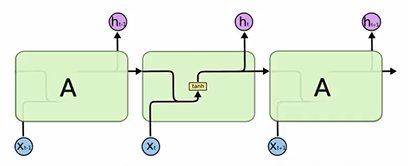

- 结构解释图

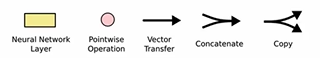

- 内部结构分析：
  - 我们把目光集中在中间的方块部分，它的输入有两部分，分别是 \( h(t-1) \) 以及 \( x(t) \)，代表上一时间步的隐层输出，以及此时间步的输入。它们进入 RNN 结构体后，会“融合”到一起，这种融合我们根据结构解释可知，是将二者进行拼接，形成新的张量 \( x(t) \)，\( h(t-1) \)。之后这个新的张量将通过一个全连接层（线性层），该层使用 tanh 作为激活函数，最终得到该时间步的输出 \( h(t) \)，它将作为下一个时间步的输入和 \( x(t+1) \) 一起进入结构体。以此类推。

- 内部结构过程演示：

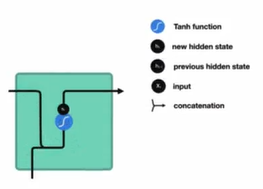

* 根据结构分析得出内部计算公式：

  $$h_t = \tanh(W_t[X_t, h_{t-1}] + b_t)$$

* 激活函数tanh的作用：
  * 用于帮助调节流经网络的值，tanh函数将值压缩在-1和1之间。

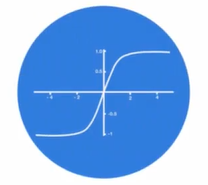

## 1.2 使用Pytorch构建RNN模型

* **位置**：在 `torch.nn` 工具包之中，通过 `torch.nn.RNN` 可调用
* **`nn.RNN` 类初始化主要参数解释**：
  * `input_size`：输入张量 x 中特征维度的大小
  * `hidden_size`：隐层张量 h 中特征维度的大小
  * `num_layers`：隐含层的数量
  * `nonlinearity`：激活函数的选择，默认是 `tanh`
* **`nn.RNN` 类实例化对象主要参数解释**：
  * `input`：输入张量 x
  * `h0`：初始化的隐层张量 h
* **`nn.RNN` 使用示例**：

In [10]:
import torch
import torch.nn as nn

rnn = nn.RNN(5, 6, 1)
input = torch.randn(1, 3, 5)
h0 = torch.randn(1, 3, 6)
output, hn = rnn(input, h0)

print(output)

print(hn)

tensor([[[-0.6434,  0.0154,  0.5651, -0.8496, -0.4148,  0.5234],
         [-0.9261, -0.6230, -0.9356, -0.9642,  0.3643,  0.3504],
         [ 0.2547,  0.5119,  0.4646,  0.5298, -0.6517,  0.0303]]],
       grad_fn=<StackBackward0>)
tensor([[[-0.6434,  0.0154,  0.5651, -0.8496, -0.4148,  0.5234],
         [-0.9261, -0.6230, -0.9356, -0.9642,  0.3643,  0.3504],
         [ 0.2547,  0.5119,  0.4646,  0.5298, -0.6517,  0.0303]]],
       grad_fn=<StackBackward0>)


## 1.3 传统RNN优缺点

### 1 传统RNN的优势：
* 由于内部结构简单，对计算资源要求低，相比之后我们要学习的RNN变体：LSTM和GRU模型参数总量少了很多，在短序列任务上性能和效果都表现优异。

### 2 传统RNN的缺点：
* 传统RNN在解决长序列之间的关联时，通过实践，证明经典RNN表现很差，原因是进行反向传播的时候，过长的序列导致梯度的计算异常，发生梯度消失或爆炸。

### 3 梯度消失或爆炸介绍
根据反向传播算法和链式法则，梯度的计算可以简化为以下公式：

$$D_n = \sigma'(z_1)w_1 \cdot \sigma'(z_2)w_2 \cdot \dots \cdot \sigma'(z_n)w_n$$

* 其中 sigmoid 的导数值域是固定的，在 [0, 0.25] 之间，而一旦公式中的 w 也小于 1，那么通过这样的公式连乘后，最终的梯度就会变得非常非常小，这种现象称作梯度消失。
* 反之，如果我们人为的增大 w 的值，使其大于 1，那么连乘就可能造成梯度过大，称作梯度爆炸。

### 梯度消失或爆炸的危害：
* 如果在训练过程中发生了梯度消失，权重无法被更新，最终导致训练失败。
* 梯度爆炸所带来的梯度过大，大幅度更新网络参数，在极端情况下，结果会溢出（NaN值）。